# Week 3 — Baseline Model & the Training Loop
### A generic, end-to-end workflow (kept deliberately simple)

Goal for the session: show the team **how a model actually gets trained** — the training loop, epoch by epoch,
on a small **subset** of data.

> **Data note:** we generate a tiny **synthetic image dataset** (5 shape classes) so this runs anywhere in
> seconds. The workflow is dataset-agnostic — Group 5 swaps in a stratified subset of PlantVillage by changing
> **Step 1 only**. Everything after that is identical.

Folded in from **Week 2**: stratified split, train-only normalization, class-imbalance weights, and *named* augmentation samples.

In [1]:
import time, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import torch, torch.nn as nn
from sklearn.model_selection import train_test_split
%matplotlib inline

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3, "font.size": 10})
print("device:", device)

device: cpu


## Step 1 — The data, and *why* we train on a subset

**Teaching point:** don't debug on the full dataset. Take a small **stratified subset** first — it trains in
seconds, so you catch pipeline bugs, a wrong learning rate, or mislabelled data *fast*. Scale up only once the
subset trains sanely. "Stratified" = the subset keeps the same class proportions as the full data.

In [2]:
CLASSES = ["disk", "ring", "square", "triangle", "bars"]
N_CLASSES, S = len(CLASSES), 32
COUNTS = [500, 380, 260, 150, 90]                       # deliberately IMBALANCED, like PlantVillage
# shared colours (disk&ring=red, square&triangle=green) => model must learn SHAPE, not colour
PALETTE = np.array([[.82,.33,.33],[.82,.33,.33],[.33,.62,.38],[.33,.62,.38],[.35,.45,.82]])

def gen_image(cls, rng):
    img = np.full((S,S,3), rng.uniform(.15,.30,3), np.float32)
    yy,xx = np.mgrid[0:S,0:S]
    cx,cy = rng.uniform(S*.4,S*.6,2); r = rng.uniform(S*.20,S*.28)
    color = np.clip(PALETTE[cls] + rng.normal(0,.05,3), 0, 1)
    if   cls==0: m = (xx-cx)**2+(yy-cy)**2 <= r**2
    elif cls==1: d=(xx-cx)**2+(yy-cy)**2; m=(d<=r**2)&(d>=(r*.55)**2)
    elif cls==2: s=r*.9; m=(np.abs(xx-cx)<=s)&(np.abs(yy-cy)<=s)
    elif cls==3: t=np.clip((yy-(cy-r))/(2*r),0,1); m=(np.abs(xx-cx)<=t*r)&(yy>=cy-r)&(yy<=cy+r)
    else:        p=max(2,int(r*.5)); m=((xx//p)%2==0)&(np.abs(xx-cx)<=r)&(np.abs(yy-cy)<=r)
    img[m] = color
    img += rng.normal(0,.06,(S,S,3)).astype(np.float32)   # a little noise so it takes a few epochs
    return np.clip(img,0,1).astype(np.float32)

rng = np.random.default_rng(SEED)
X_full = np.stack([gen_image(c,rng) for c,n in enumerate(COUNTS) for _ in range(n)])
y_full = np.array([c for c,n in enumerate(COUNTS) for _ in range(n)])
print("full dataset:", X_full.shape, "| classes:", dict(zip(CLASSES, np.bincount(y_full))))

full dataset: (1380, 32, 32, 3) | classes: {'disk': np.int64(500), 'ring': np.int64(380), 'square': np.int64(260), 'triangle': np.int64(150), 'bars': np.int64(90)}


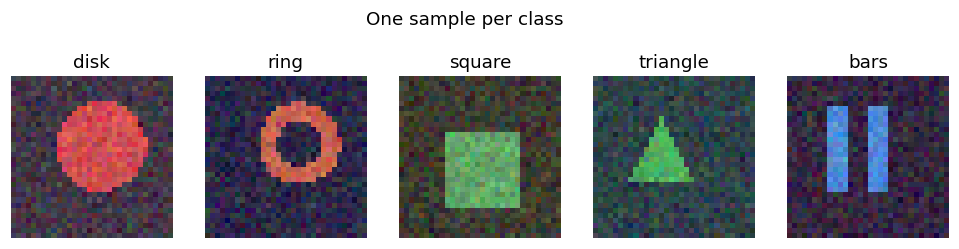

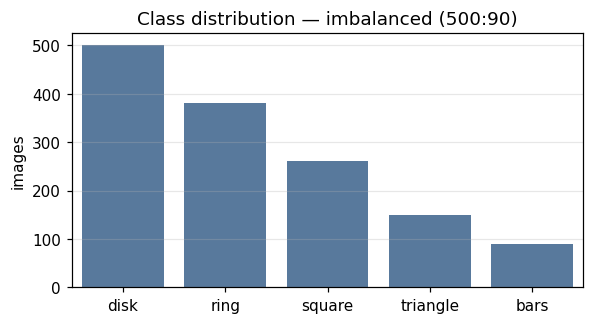

In [ ]:
fig, ax = plt.subplots(1, N_CLASSES, figsize=(11,2.4))
for c in range(N_CLASSES):
    ax[c].imshow(X_full[np.argmax(y_full==c)]); ax[c].set_title(CLASSES[c]); ax[c].axis("off")
fig.suptitle("One sample per class", y=1.05); plt.show()

plt.figure(figsize=(6,3))
sns.barplot(x=CLASSES, y=np.bincount(y_full), color="#4C78A8")
plt.title(f"Class distribution — imbalanced ({max(COUNTS)}:{min(COUNTS)})"); plt.ylabel("images"); plt.show() #3x32x32

## Step 2 — Preprocessing recap (Week 2 inputs, applied)

Four things from last week, shown quickly before we train:
1. **Stratified subset** for fast prototyping.
2. **Stratified train / val / test split** — every class present in each split.
3. **Normalization stats from the *training* split only** — never peek at val/test.
4. **Imbalance** — compute class weights now; they plug straight into the loss in Step 4.

subset 690  ->  train 483 | val 103 | test 104


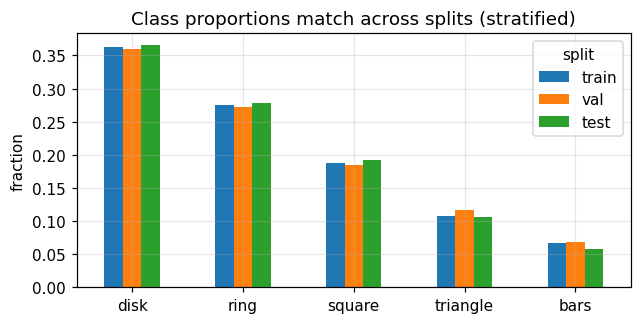

In [4]:
# stratified subset (~50%), then stratified 70/15/15 split
X_sub,_,y_sub,_   = train_test_split(X_full, y_full, train_size=0.5, stratify=y_full, random_state=SEED)
X_tr,X_tmp,y_tr,y_tmp = train_test_split(X_sub, y_sub, test_size=0.30, stratify=y_sub, random_state=SEED)
X_va,X_te,y_va,y_te   = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
print(f"subset {len(X_sub)}  ->  train {len(X_tr)} | val {len(X_va)} | test {len(X_te)}")

prop = pd.DataFrame({s: np.bincount(y,minlength=N_CLASSES)/len(y)
                     for s,y in [("train",y_tr),("val",y_va),("test",y_te)]}, index=CLASSES)
prop.plot(kind="bar", figsize=(6.5,3)); plt.title("Class proportions match across splits (stratified)")
plt.ylabel("fraction"); plt.xticks(rotation=0); plt.legend(title="split"); plt.show()

train mean: [0.291 0.256 0.246] | train std: [0.194 0.118 0.1  ]


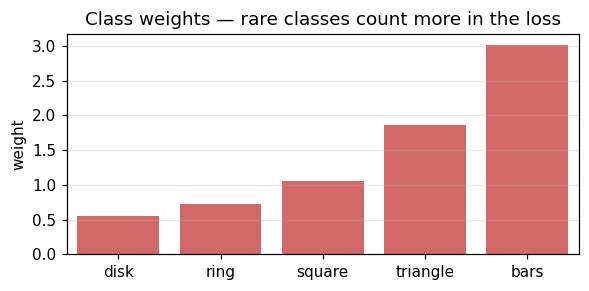

In [5]:
# normalization from TRAIN ONLY
mean, std = X_tr.mean((0,1,2)), X_tr.std((0,1,2))
print("train mean:", mean.round(3), "| train std:", std.round(3))
def to_tensor(X):
    t = torch.tensor(X).permute(0,3,1,2)
    return ((t - torch.tensor(mean).view(1,3,1,1)) / torch.tensor(std).view(1,3,1,1)).float()

# class weights from TRAIN ONLY (inverse frequency) -> used by the loss in Step 4
cnt = np.bincount(y_tr, minlength=N_CLASSES)
class_w = cnt.sum() / (N_CLASSES * cnt)
w = torch.tensor(class_w, dtype=torch.float32, device=device)
plt.figure(figsize=(6,2.6)); sns.barplot(x=CLASSES, y=class_w, color="#E45756")
plt.title("Class weights — rare classes count more in the loss"); plt.ylabel("weight"); plt.show()

def loader(X,y,bs=64,shuffle=False):
    ds = torch.utils.data.TensorDataset(to_tensor(X), torch.tensor(y))
    return torch.utils.data.DataLoader(ds, batch_size=bs, shuffle=shuffle)
train_loader = loader(X_tr,y_tr,shuffle=True); val_loader = loader(X_va,y_va); test_loader = loader(X_te,y_te)

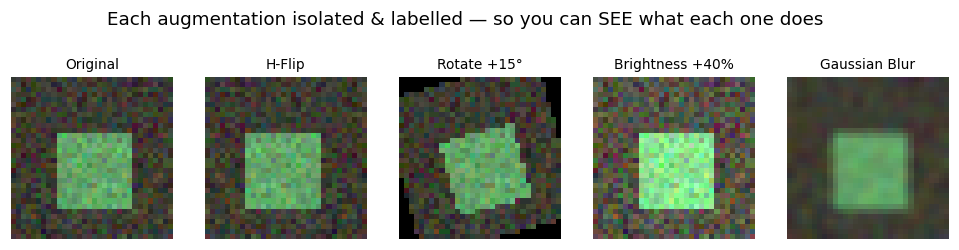

In [6]:
# Augmentation, shown ONE effect at a time and NAMED (the Week-2 fix: label your augmentations)
from torchvision import transforms
from PIL import Image
pil = Image.fromarray((X_full[np.argmax(y_full==2)]*255).astype("uint8"))
named = {
 "Original":        lambda im: im,
 "H-Flip":          transforms.RandomHorizontalFlip(p=1.0),
 "Rotate +15°":     transforms.RandomRotation((15,15)),
 "Brightness +40%": transforms.ColorJitter(brightness=(1.4,1.4)),
 "Gaussian Blur":   transforms.GaussianBlur(3, sigma=(1.2,1.2)),
}
fig, ax = plt.subplots(1, len(named), figsize=(11,2.3))
for a,(name,tf) in zip(ax, named.items()):
    a.imshow(tf(pil)); a.set_title(name, fontsize=9); a.axis("off")
fig.suptitle("Each augmentation isolated & labelled — so you can SEE what each one does", y=1.08); plt.show()

## Step 3 — The baseline model (SimpleCNN)

This week's model is the **baseline**: a compact 4-block convolutional network — no pretraining, no residual
connections. It's the simplest thing that can plausibly learn the task. *Why start here?* So that later, when
you add ResNet-50, you can **measure** what the fancy model actually bought you instead of assuming it. (The
ResNet-50 comparison and proper metrics come in a later session — see the Appendix for the code.)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes, w=32):
        super().__init__()
        block = lambda i,o: nn.Sequential(nn.Conv2d(i,o,3,padding=1), nn.BatchNorm2d(o),
                                          nn.ReLU(), nn.MaxPool2d(2))
        self.features = nn.Sequential(block(3,w), block(w,2*w), block(2*w,4*w), block(4*w,4*w))
        self.head     = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(4*w, n_classes))
    def forward(self, x):
        return self.head(self.features(x))

print("SimpleCNN parameters:", f"{sum(p.numel() for p in SimpleCNN(N_CLASSES).parameters()):,}")

# quick sanity check: a correct pipeline can memorise ONE batch (loss -> ~0)
xb,yb = next(iter(train_loader)); m = SimpleCNN(N_CLASSES).to(device)
opt = torch.optim.Adam(m.parameters(), 1e-3); crit = nn.CrossEntropyLoss()
for _ in range(50):
    loss = crit(m(xb.to(device)), yb.to(device)); opt.zero_grad(); loss.backward(); opt.step()
print(f"single-batch loss after 50 steps: {loss.item():.4f}  (near 0 => the wiring works)")

# 3x32x32 images 
# 3 filter -> 32 channels
# 32 channels -> 
# 128 channels output, 32x32 -> 128x4x4
# []


SimpleCNN parameters: 242,181


single-batch loss after 50 steps: 0.0024  (near 0 => the wiring works)


## Step 4 — The training loop (the heart of this week)

Everything below repeats this, once per **epoch** (one full pass over the training data):

| step | code | what it does |
|------|------|--------------|
| 1. forward | `out = model(xb)` | run the batch through the network |
| 2. loss | `loss = crit(out, yb)` | how wrong are we? |
| 3. zero grads | `opt.zero_grad()` | clear last step's gradients (they accumulate otherwise) |
| 4. backward | `loss.backward()` | back-propagate — autograd computes gradients |
| 5. step | `opt.step()` | nudge the weights to reduce the loss |

Two switches matter: **`model.train()` vs `model.eval()`** (changes BatchNorm/Dropout behaviour) and
**`torch.no_grad()`** on validation (no weight updates there — we only *measure*).

In [ ]:
def run_epoch(model, loader, crit, opt=None):
    is_train = opt is not None
    model.train(is_train)                         # train() vs eval(): affects BatchNorm
    loss_sum = correct = total = 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        with torch.set_grad_enabled(is_train):
            out  = model(xb)                      # 1. forward
            loss = crit(out, yb)                  # 2. loss
            if is_train:
                opt.zero_grad()                   # 3. clear old gradients
                loss.backward()                   # 4. backprop
                opt.step()                        # 5. update weights
        loss_sum += loss.item()*len(xb)
        correct  += (out.argmax(1) == yb).sum().item(); total += len(xb)
    return loss_sum/total, correct/total

model = SimpleCNN(N_CLASSES).to(device)
opt   = torch.optim.Adam(model.parameters(), lr=1e-3)
crit  = nn.CrossEntropyLoss(weight=w)             # <-- class weights => imbalance handled here
EPOCHS = 15

hist = {k: [] for k in ["tr_loss","tr_acc","va_loss","va_acc"]}
for ep in range(EPOCHS):
    tl, ta = run_epoch(model, train_loader, crit, opt)   # TRAIN pass (weights update)
    vl, va = run_epoch(model, val_loader,   crit)        # VAL pass  (no update)
    for k,v in zip(hist, [tl,ta,vl,va]): hist[k].append(v)
    print(f"epoch {ep+1:2d}/{EPOCHS} | train loss {tl:.3f} acc {ta:.3f} | val loss {vl:.3f} acc {va:.3f}")

epoch  1/15 | train loss 0.716 acc 0.774 | val loss 0.864 acc 0.718


epoch  2/15 | train loss 0.202 acc 0.954 | val loss 0.566 acc 0.738


epoch  3/15 | train loss 0.069 acc 0.998 | val loss 0.180 acc 0.951


epoch  4/15 | train loss 0.044 acc 0.996 | val loss 0.053 acc 1.000


epoch  5/15 | train loss 0.014 acc 1.000 | val loss 0.015 acc 1.000


...

epoch 11/15 | train loss 0.002 acc 1.000 | val loss 0.003 acc 1.000


epoch 12/15 | train loss 0.002 acc 1.000 | val loss 0.003 acc 1.000


epoch 13/15 | train loss 0.002 acc 1.000 | val loss 0.002 acc 1.000


epoch 14/15 | train loss 0.002 acc 1.000 | val loss 0.002 acc 1.000


epoch 15/15 | train loss 0.002 acc 1.000 | val loss 0.002 acc 1.000


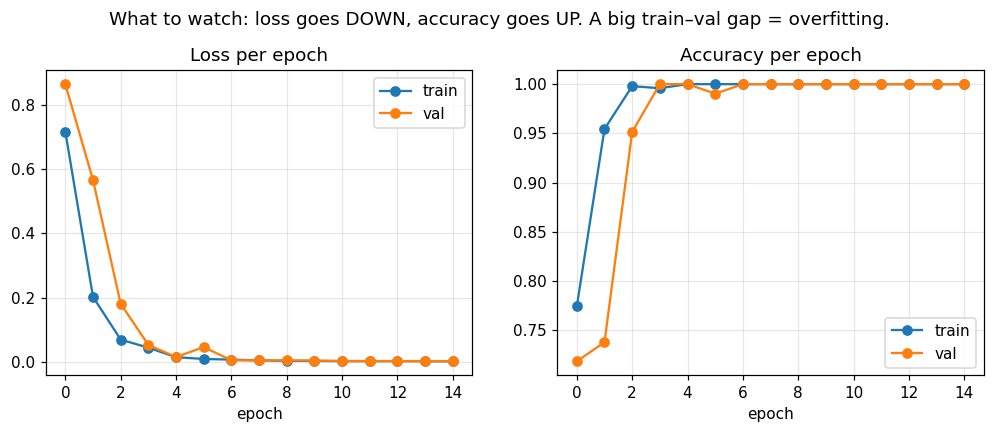

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(11,3.6))
ax[0].plot(hist["tr_loss"], "o-", label="train"); ax[0].plot(hist["va_loss"], "o-", label="val")
ax[0].set_title("Loss per epoch"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(hist["tr_acc"], "o-", label="train"); ax[1].plot(hist["va_acc"], "o-", label="val")
ax[1].set_title("Accuracy per epoch"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.suptitle("What to watch: loss goes DOWN, accuracy goes UP. A big train–val gap = overfitting.", y=1.03)
plt.show()

## Wrap-up & worktime

**You just saw the whole loop:** data → subset → split → normalize → baseline model → train epoch-by-epoch → read the curves.
---
